# Kruskal–Wallis toets: doorlooptijd per incidentcategorie

## Doel
Onderzoeken of de doorlooptijd (**totale minuten open**) verschilt tussen incidentcategorieën.
Omdat doorlooptijden vaak scheef verdeeld zijn, gebruiken we een **niet-parametrische toets**: de **Kruskal–Wallis-toets**.

## Dataset
Gebruikte kolommen:
- incident nummer (voor deduplicatie)
- Incident categorie
- totale minuten open

## Stappen
1. Data inladen
2. Duplicaten verwijderen (1 rij per incidentnummer)
3. Opschonen (missende waarden, niet-numeriek, ≤ 0)
4. Filter: minimaal *min_n* waarnemingen per categorie
5. Kruskal–Wallis + effectgrootte (ε²)
6. Boxplot (vaste volgorde, ook met log-schaal)

In [21]:
pip install pandas numpy scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal

#### 1. Data inladen

In [23]:
df = pd.read_csv("incidenten_export.csv")

print("Kolommen:", df.columns.tolist())
df.head()


Kolommen: ['incident nummer', 'Incident categorie', 'totale minuten open', 'Prioriteit incident']


,incident nummer,Incident categorie,totale minuten open,Prioriteit incident
0,1065298,2e lijns (Doorgezette incidenten),19902,E8
1,1124826,Hardware / Werkplekbeheer,133,E8
2,1156332,2e lijns (Doorgezette incidenten),1270,E8
3,1183663,Functioneel beheer,327156,E8
4,1183923,Functioneel beheer,327159,E8


#### 2. Deduplicatie: 1 rij per incident

In [24]:
df["incident nummer"] = df["incident nummer"].astype(str).str.strip()

dup_count = df.duplicated(subset=["incident nummer"]).sum()
print("Aantal dubbele incidentnummers:", dup_count)

# Strategie: eerste voorkomen houden (sluit meestal aan op Power BI)
df = df.drop_duplicates(subset=["incident nummer"], keep="first")
print("N na deduplicatie:", len(df))

Aantal dubbele incidentnummers: 51
N na deduplicatie: 25758


#### 3.Selectie + opschoning

In [25]:
df_kw = df[["incident nummer", "Incident categorie", "totale minuten open"]].copy()

# Missende waarden verwijderen
df_kw = df_kw.dropna(subset=["Incident categorie", "totale minuten open"])

# Numeriek maken
df_kw["totale minuten open"] = pd.to_numeric(df_kw["totale minuten open"], errors="coerce")
df_kw = df_kw.dropna(subset=["totale minuten open"])

# Niet-logische waarden eruit
df_kw = df_kw[df_kw["totale minuten open"] > 0]

print("N na opschoning:", len(df_kw))
print("Aantal categorieën:", df_kw["Incident categorie"].nunique())

N na opschoning: 25758
Aantal categorieën: 6


#### 4. Filter op voldoende waarnemingen per categorie

In statistische analyses wordt vaak een minimale groepsgrootte gehanteerd om instabiele of
niet-representatieve resultaten te voorkomen. In deze analyse is een ondergrens van 30
waarnemingen per incidentcategorie aangehouden als **controlemaatregel**.

In de gebruikte dataset voldoen alle incidentcategorieën ruimschoots aan deze voorwaarde.
Het filter heeft daardoor **geen invloed op de uiteindelijke dataset**, maar is bewust
opgenomen om de methodologische robuustheid en reproduceerbaarheid van de analyse te
waarborgen.

In [26]:
min_n = 30
counts = df_kw["Incident categorie"].value_counts()
keep_cats = counts[counts >= min_n].index

df_kw = df_kw[df_kw["Incident categorie"].isin(keep_cats)].copy()

print("Categorieën >= min_n:", len(keep_cats))
print("N na filter:", len(df_kw))

Categorieën >= min_n: 6
N na filter: 25758


#### 5. Vaste volgorde

In [27]:
order = [
    "1e lijns beheer (Helpdesk)",
    "2e lijns (Doorgezette incidenten)",
    "3e lijns (Technische incidenten)",
    "Functioneel beheer",
    "Hardware / Werkplekbeheer",
    "Telefonie / Communicatie"
]

# Alleen categorieën pakken die ook echt in de data voorkomen
order = [c for c in order if c in df_kw["Incident categorie"].unique()]

df_kw = df_kw[df_kw["Incident categorie"].isin(order)].copy()
df_kw["Incident categorie"] = pd.Categorical(df_kw["Incident categorie"], categories=order, ordered=True)

print("Gebruikte categorie-volgorde:", order)
print("N (na volgorde-filter):", len(df_kw))

Gebruikte categorie-volgorde: ['1e lijns beheer (Helpdesk)', '2e lijns (Doorgezette incidenten)', '3e lijns (Technische incidenten)', 'Functioneel beheer', 'Hardware / Werkplekbeheer', 'Telefonie / Communicatie']
N (na volgorde-filter): 25758


#### 6. Kruskal–Wallis toets

In [28]:
groepen = [df_kw.loc[df_kw["Incident categorie"] == c, "totale minuten open"].values for c in order]

H, p = kruskal(*groepen)

k = len(order)
n = len(df_kw)

# Effectgrootte epsilon squared (ε²)
epsilon_sq = (H - k + 1) / (n - k)

# Interpretatie vuistregels
if epsilon_sq < 0.01:
    interpretatie = "zeer klein effect"
elif epsilon_sq < 0.06:
    interpretatie = "klein effect"
elif epsilon_sq < 0.14:
    interpretatie = "middelgroot effect"
else:
    interpretatie = "groot effect"

p_rapport = "< 0,001" if (p == 0.0 or p < 0.001) else f"= {p:.3f}"

print("Kruskal–Wallis resultaat")
print(f"H = {H:.3f}")
print(f"p {p_rapport}")
print(f"ε² = {epsilon_sq:.4f}  → {interpretatie}")
print(f"(k={k}, n={n})")

Kruskal–Wallis resultaat
H = 4953.608
p < 0,001
ε² = 0.1922  → groot effect
(k=6, n=25758)


#### 7. Boxplot met log-schaal

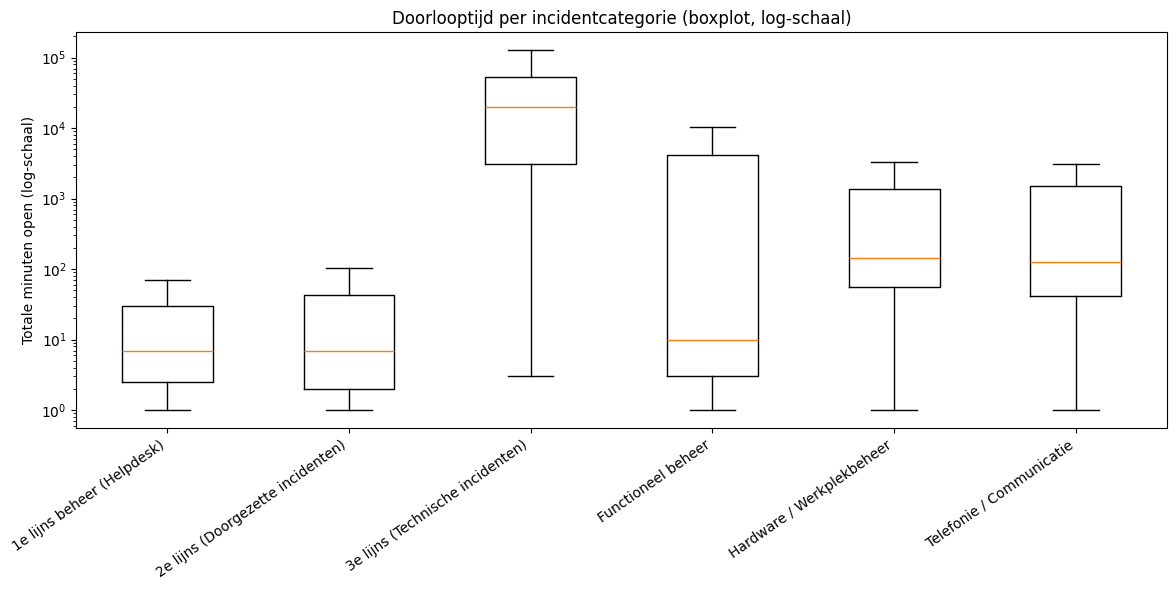

In [29]:
data = [df_kw.loc[df_kw["Incident categorie"] == c, "totale minuten open"].values for c in order]

plt.figure(figsize=(12, 6))
plt.boxplot(data, tick_labels=order, showfliers=False)
plt.yscale("log")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Totale minuten open (log-schaal)")
plt.title("Doorlooptijd per incidentcategorie (boxplot, log-schaal)")
plt.tight_layout()
plt.show()

### Rapportage

In [30]:
print(
    "Om te toetsen of de doorlooptijd (totale minuten open) verschilt tussen incidentcategorieën "
    f"is een Kruskal–Wallis-toets uitgevoerd. De toets toont een significant verschil (H = {H:.1f}, p {p_rapport}). "
    f"De effectgrootte is ε² = {epsilon_sq:.2f}, wat wijst op een {interpretatie}. "
    "De boxplot (log-schaal) laat visueel zien dat de medianen en spreidingen per categorie duidelijk verschillen."
)

Om te toetsen of de doorlooptijd (totale minuten open) verschilt tussen incidentcategorieën is een Kruskal–Wallis-toets uitgevoerd. De toets toont een significant verschil (H = 4953.6, p < 0,001). De effectgrootte is ε² = 0.19, wat wijst op een groot effect. De boxplot (log-schaal) laat visueel zien dat de medianen en spreidingen per categorie duidelijk verschillen.
